<a href="https://colab.research.google.com/github/Zeinab15/Data-Analysis-Projects/blob/main/G8_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

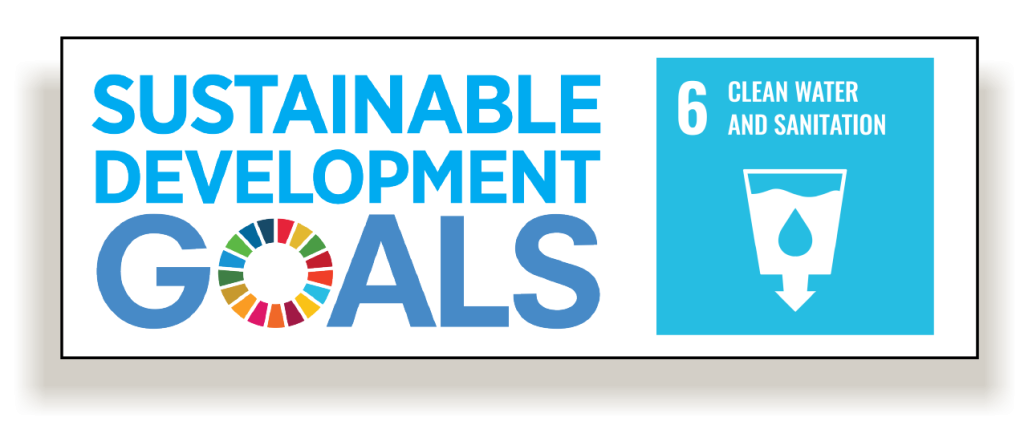

 ***Predicting Water Quality Using Machine Learning***

Group (8) members:

1.   Zeinab Mohmmed
2.   Lina Ahmed
3.  Bacoro dit Elhadji Lansar





# Introduction:

Water quality is essential for human health and the environment. Ensuring access to clean water and sanitation is a critical goal outlined in the United Nations Sustainable Development Goal (SDG) 6.

In this project, we aim to develop a machine learning model that predicts water quality based on various parameters.

By accurately predicting water quality, we can take proactive measures to address potential issues, thus contributing to the global effort of providing clean water and sanitation for all.

# Dataset:

## A brief description

We are utilizing a dataset from Kaggle, which includes various water quality measurements and assessments related to potability, indicating the suitability of water for human consumption. The dataset's main purpose is to provide insights into different water quality parameters and help determine whether the water is safe to drink. Each entry in the dataset represents a water sample with specific attributes, and the "Potability" column signifies if the water is suitable for consumption.

## Dataset source

Kaggle
[Click here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability)


## key features and their descriptions.

**Columns:**

* **pH:** The pH level of the water.
* **Hardness:** Water hardness, a measure of mineral content.
* **Solids:** Total dissolved solids in the water.
* **Chloramines:** Chloramines concentration in the water.
* **Sulfate:** Sulfate concentration in the water.
* **Conductivity:** Electrical conductivity of the water.
* **Organic_carbon:** Organic carbon content in the water.
* **Trihalomethanes:** Trihalomethanes concentration in the water.
* **Turbidity:** Turbidity level, a measure of water clarity.
* **Potability:** Target variable; indicates water potability with values 1 (potable) and 0 (not potable).

# Methodology:

## Uploading data

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Checks if the CSV file exist
from google.colab import files
import os
if not os.path.exists('water_potability.csv'):
  uploaded = files.upload()

## Read the data

In [ ]:
df = pd.read_csv('water_potability.csv')

## Data Exploration and Understanding

In [ ]:
df.shape

(3276, 10)

In [ ]:
df.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.duplicated().sum()

0

In [ ]:
pd.set_option('display.float_format', lambda x : '%.3f' % x)
df.describe().transpose()  #Statistics

,count,mean,std,min,25%,50%,75%,max
ph,2785.000,7.081,1.594,0.000,6.093,7.037,8.062,14.000
Hardness,3276.000,196.369,32.880,47.432,176.851,196.968,216.667,323.124
Solids,3276.000,22014.093,8768.571,320.943,15666.690,20927.834,27332.762,61227.196
Chloramines,3276.000,7.122,1.583,0.352,6.127,7.130,8.115,13.127
Sulfate,2495.000,333.776,41.417,129.000,307.699,333.074,359.950,481.031
Conductivity,3276.000,426.205,80.824,181.484,365.734,421.885,481.792,753.343
Organic_carbon,3276.000,14.285,3.308,2.200,12.066,14.218,16.558,28.300
Trihalomethanes,3114.000,66.396,16.175,0.738,55.845,66.622,77.337,124.000
Turbidity,3276.000,3.967,0.780,1.450,3.440,3.955,4.500,6.739
Potability,3276.000,0.390,0.488,0.000,0.000,0.000,1.000,1.000


## Deal with null values

In [ ]:
df.isnull().sum()


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


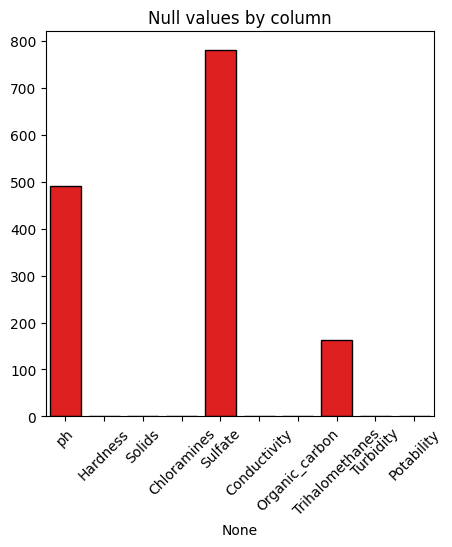

In [ ]:
# Check ISNA sum
isna_sum = df.isna().sum()
plt.figure(figsize=(5, 5))
sns.barplot(x=isna_sum.index, y=isna_sum.values, color='red', edgecolor='black')
plt.title('Null values by column')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Calculate the mean of specific fields
mean_ph = df['ph'].mean()
mean_sulfate = df['Sulfate'].mean()
mean_trihalomethanes = df['Trihalomethanes'].mean()

# Print the results
print(f'Mean pH: {mean_ph:.2f}')
print(f'Mean Sulfate: {mean_sulfate:.2f}')
print(f'Mean Trihalomethanes: {mean_trihalomethanes:.2f}')

Mean pH: 7.08
Mean Sulfate: 333.78
Mean Trihalomethanes: 66.40


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(df)
df = pd.DataFrame(data_imputed, columns=df.columns)
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [ ]:
pd.set_option('display.float_format', lambda x : '%.3f' % x)
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ph,3276.000,7.081,1.470,0.000,6.278,7.081,7.870,14.000
Hardness,3276.000,196.369,32.880,47.432,176.851,196.968,216.667,323.124
Solids,3276.000,22014.093,8768.571,320.943,15666.690,20927.834,27332.762,61227.196
Chloramines,3276.000,7.122,1.583,0.352,6.127,7.130,8.115,13.127
Sulfate,3276.000,333.776,36.143,129.000,317.095,333.776,350.386,481.031
Conductivity,3276.000,426.205,80.824,181.484,365.734,421.885,481.792,753.343
Organic_carbon,3276.000,14.285,3.308,2.200,12.066,14.218,16.558,28.300
Trihalomethanes,3276.000,66.396,15.770,0.738,56.648,66.396,76.667,124.000
Turbidity,3276.000,3.967,0.780,1.450,3.440,3.955,4.500,6.739
Potability,3276.000,0.390,0.488,0.000,0.000,0.000,1.000,1.000


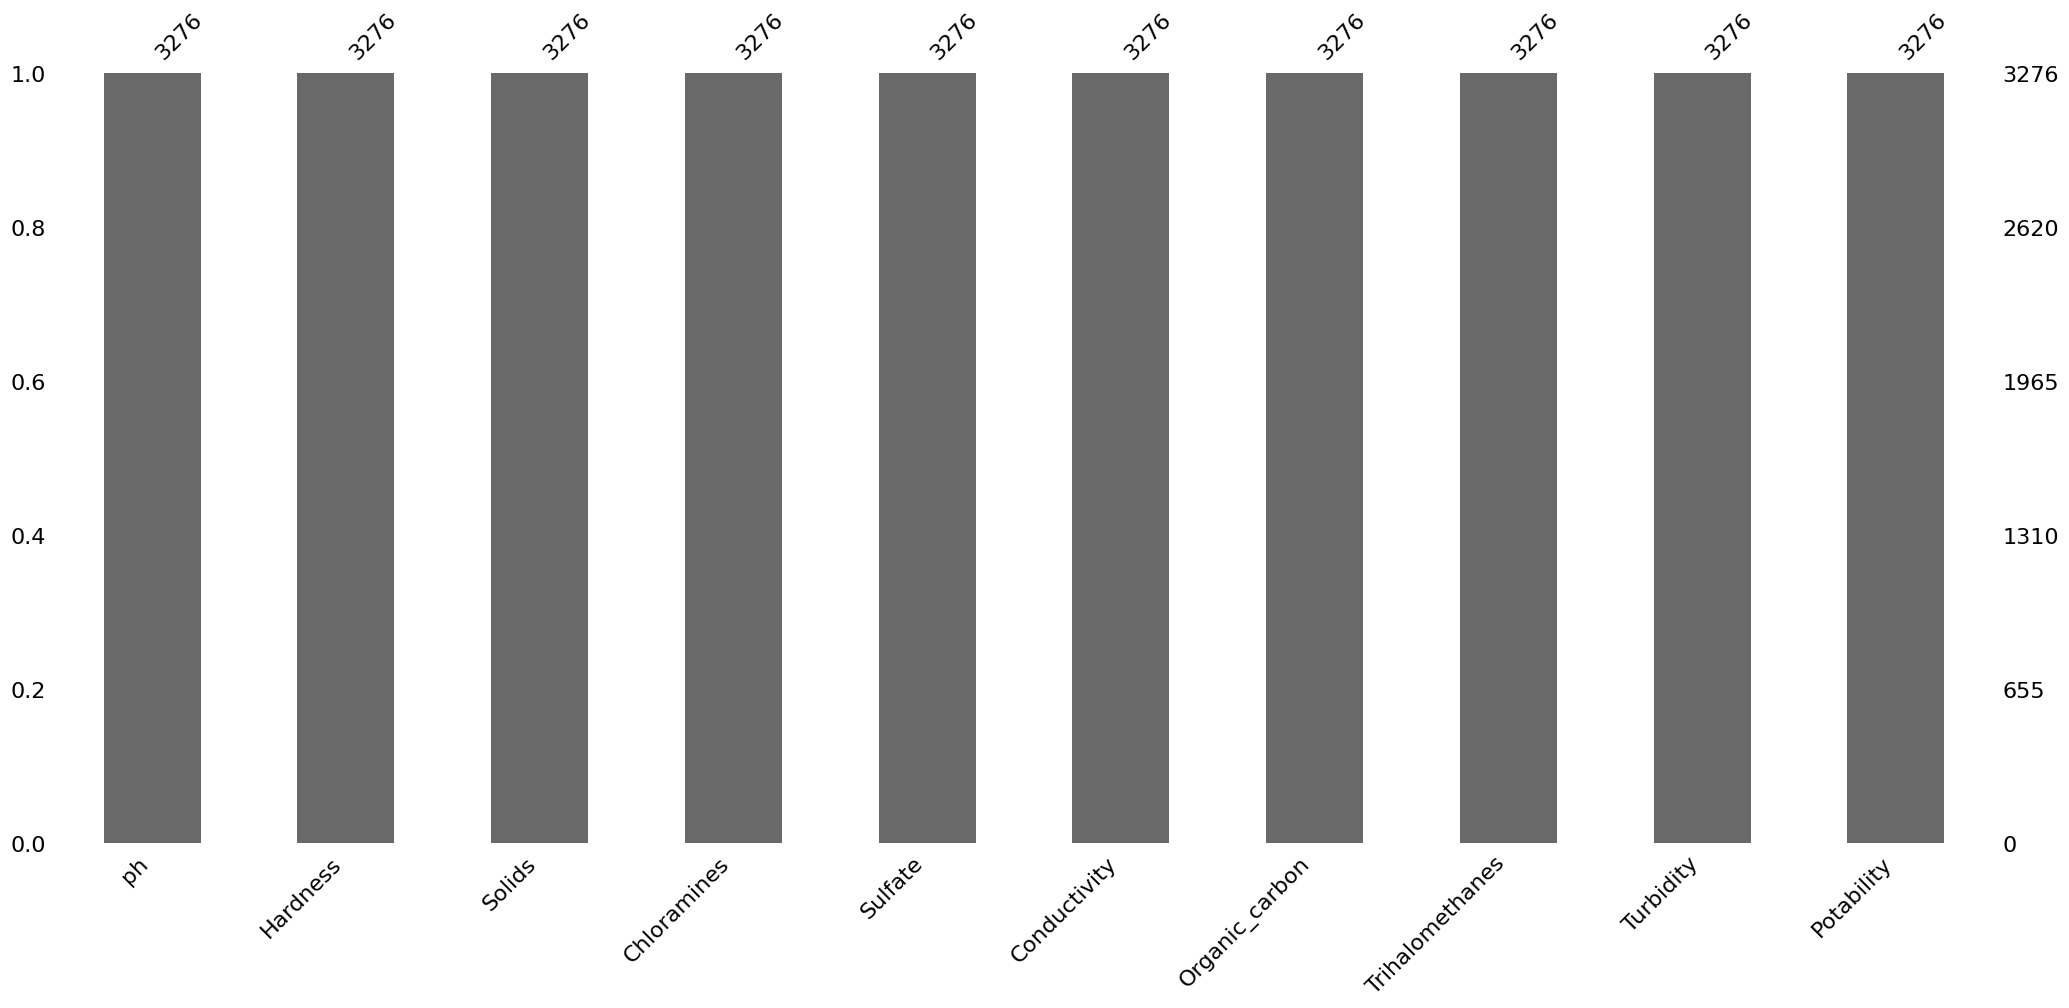

In [ ]:
#Visualise missing values
import matplotlib.pyplot as plt
import missingno as msno
msno.bar(df)
plt.show()

## Deal with outliers

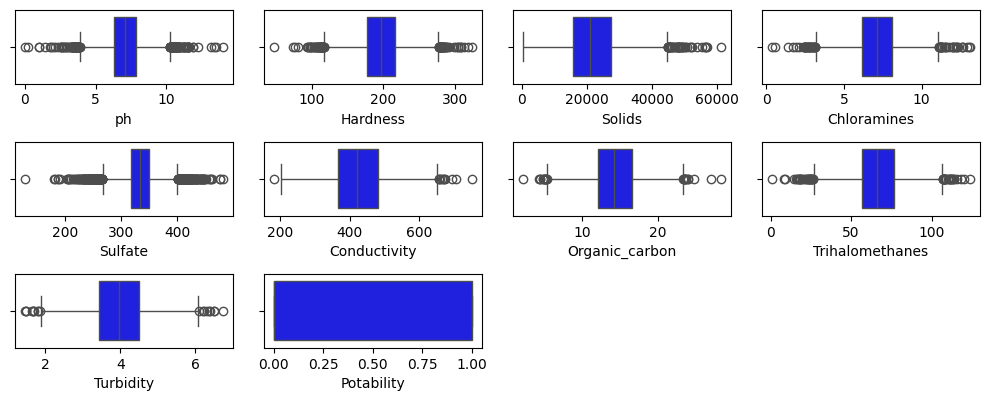

In [ ]:
#Check the ouliers using boxplot

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 5))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df[col], color='blue')

plt.tight_layout()
plt.show()

In [ ]:
#Trim the Oulites using Z-Score method
columns_with_outliers = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
for column in columns_with_outliers:
    lower_limit = df[column].mean() - 3 * df[column].std()
    upper_limit = df[column].mean() + 3 * df[column].std()
    columns_with_outliers = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
    df = df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]

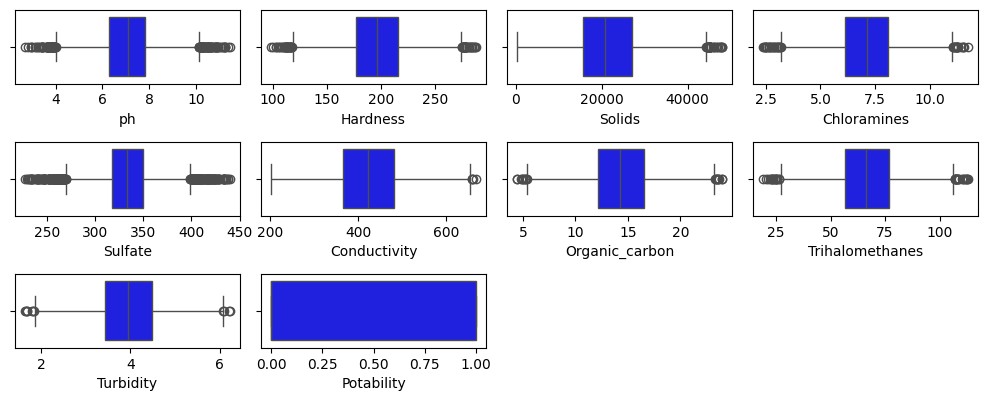

In [ ]:
#Check after triming the outliers

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 5))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df[col], color='blue')

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis (EDA)**
Visualize the data to identify patterns and correlations.
Use plots and graphs to understand the distribution of each feature.

In [ ]:
# Calculate skewness for each column
skewness = df.skew()

# Print the skewness
print(skewness)

ph                 0.073
Hardness          -0.028
Solids             0.466
Chloramines       -0.064
Sulfate            0.071
Conductivity       0.226
Organic_carbon     0.001
Trihalomethanes   -0.025
Turbidity         -0.029
Potability         0.484
dtype: float64


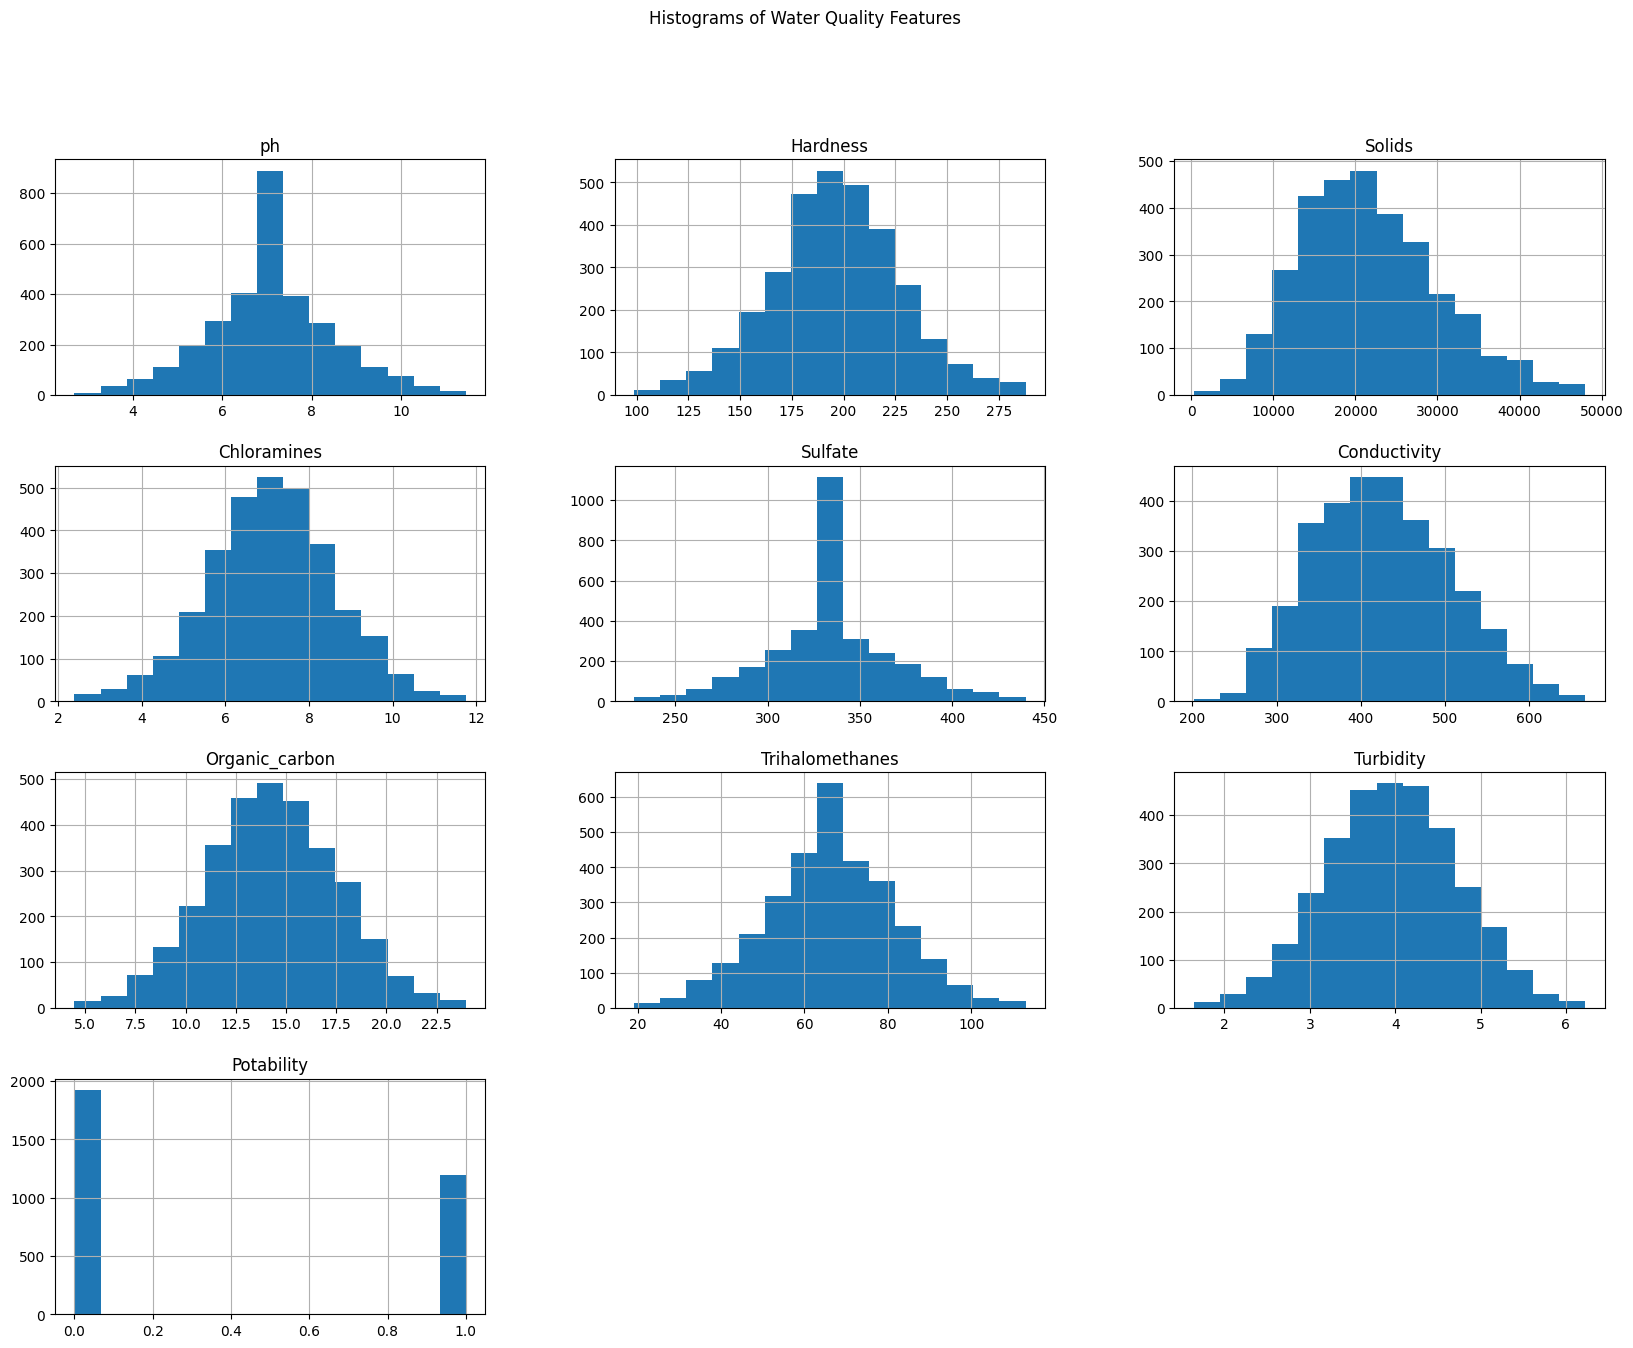

In [ ]:
df.hist(bins=15, figsize=(20, 15))
plt.suptitle('Histograms of Water Quality Features')
plt.show()


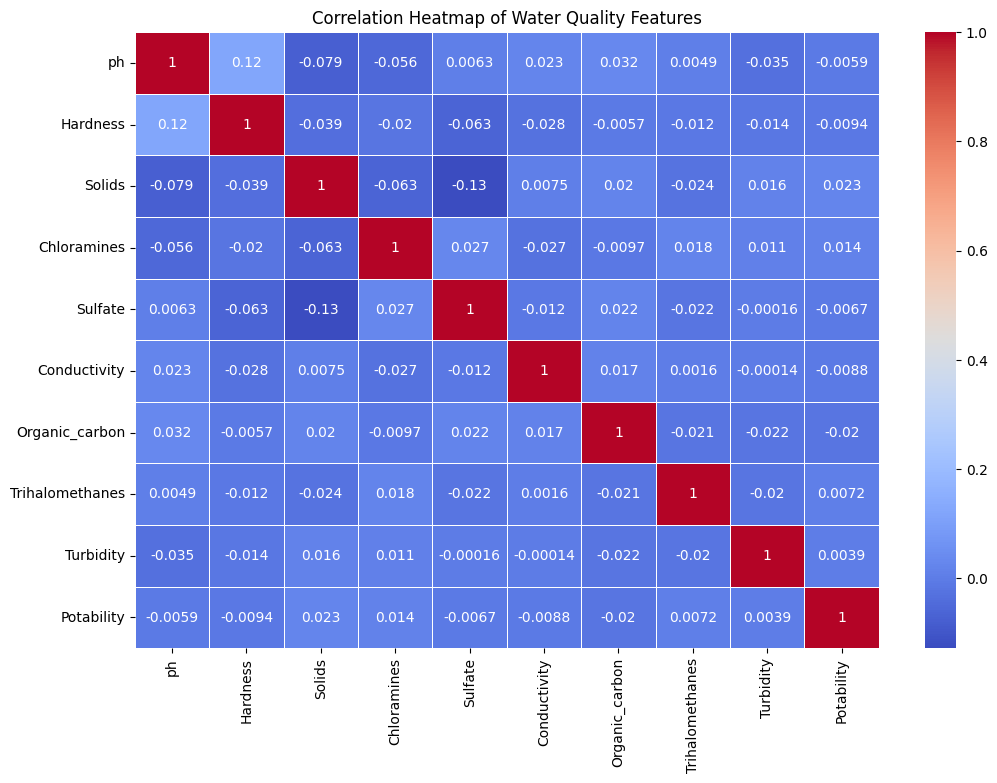

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Water Quality Features')
plt.show()


In [ ]:
import plotly.express as px

fig = px.scatter(df, x='ph', y='Hardness', color='Potability', title='pH vs Hardness by Potability')
fig.show()

# Pair Plot in Plotly
fig = px.scatter_matrix(df, dimensions=['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity'], color='Potability')
fig.show()


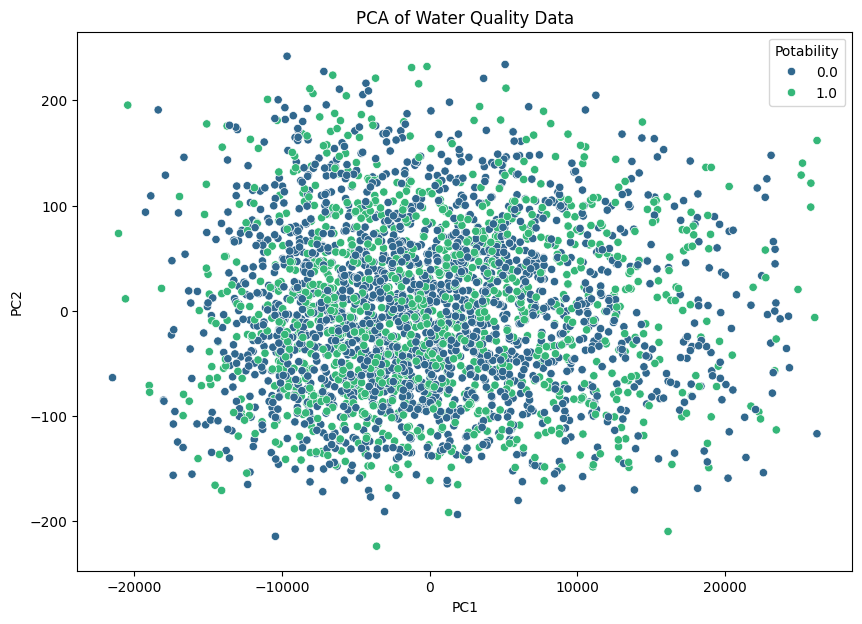

In [ ]:
from sklearn.decomposition import PCA

X = df.drop('Potability', axis=1)
y = df['Potability']
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Potability'] = y.values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Potability', palette='viridis')
plt.title('PCA of Water Quality Data')
plt.show()


#### Feature Engineering for Water Quality Prediction

It Demonstrates the process of feature engineering, scaling, encoding, and training a model using a pipeline

**Model Selection**


1- RandomForestClassifier :


Since our target variable is binary (potable vs. not potable), classification algorithms are appropriate.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pickle
from sklearn.model_selection import GridSearchCV

# Prepare data
X = df[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']]
y = df['Potability']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

report = classification_report(y_test, y_pred)
print(report)

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

roc_auc = roc_auc_score(y_test, y_pred)
print(f'ROC AUC: {roc_auc}')

import pickle

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
# make prediction
y_pred = best_model.predict(X_test)
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

Accuracy: 0.6875
              precision    recall  f1-score   support

         0.0       0.70      0.89      0.78       412
         1.0       0.65      0.34      0.45       244

    accuracy                           0.69       656
   macro avg       0.67      0.62      0.61       656
weighted avg       0.68      0.69      0.66       656

[[368  44]
 [161  83]]
ROC AUC: 0.6166839089606876


## 2- K-cross validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score




# Prepare features (X) and target (y)
X = df[['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']]
y = df['Potability']

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform k-fold cross-validation
k = 5  # Number of folds
cv_scores = cross_val_score(model, X, y, cv=k, scoring='accuracy')

# Calculate the mean and standard deviation of the cross-validation scores
mean_cv_score = np.mean(cv_scores)
std_cv_score = np.std(cv_scores)

# Print the results
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {mean_cv_score:.2f}')
print(f'Standard deviation of cross-validation scores: {std_cv_score:.2f}')
 # Evaluate Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'ROC AUC: {roc_auc}')


Cross-validation scores: [0.62042683 0.65343511 0.6519084  0.60458015 0.68396947]
Mean cross-validation score: 0.64
Standard deviation of cross-validation scores: 0.03
Accuracy: 0.6783536585365854
Precision: 0.6187050359712231
Recall: 0.3524590163934426
F1 Score: 0.4490861618798956
ROC AUC: 0.6119091198472068


### 3- Support Vector Machine (SVM)


In [ ]:
from sklearn import svm
svm = svm.SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6280487804878049


#### 4- K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.5411585365853658


In [ ]:
!pip install streamlit
!pip install pyngrok


In [ ]:
%%writefile app.py
import streamlit as st

Overwriting app.py


In [ ]:
!streamlit run /usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.148.117.252:8501



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Creating new features
df['Solids_log'] = df['Solids'].apply(lambda x: np.log(x + 1))

# Transforming existing features
df['Sulfate_binned'] = pd.cut(df['Sulfate'], bins=[0, 100, 200, 300, 400], labels=['Low', 'Medium', 'High', 'Very High'])

# Separating features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Encoding categorical variables
categorical_features = ['Sulfate_binned']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Create a preprocessing and modeling pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier())])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Evaluate the model
y_pred = pipeline.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))


Accuracy: 0.6783536585365854
Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.88      0.78       412
         1.0       0.63      0.33      0.43       244

    accuracy                           0.68       656
   macro avg       0.66      0.61      0.60       656
weighted avg       0.67      0.68      0.65       656



### Comaparaison of Model

In [ ]:
import streamlit as st
import pandas as pd
import pickle

st.set_page_config(page_title='Water Quality Prediction', layout='wide')

# Add header image


# Custom CSS for styling
st.markdown("""
<style>
    # .main { background-color: #f4f4f4; }
    .title { font-size: 32px; font-weight: bold; color: #333; }
    .input-box { margin: 20px 0; }
    .button { background-color: #007bff; color: #fff; border: none; padding: 10px 20px; border-radius: 5px; }
    .button:hover { background-color: #0056b3; }
</style>
""", unsafe_allow_html=True)

st.markdown('<h1 class="title">Water Quality Prediction</h1>', unsafe_allow_html=True)
st.write("Enter the water quality parameters below to predict whether the water is potable.")

# Layout with columns
col1, col2 = st.columns(2)
with col1:
    ph = st.number_input('pH level', min_value=0.0, max_value=14.0, value=7.0)
    hardness = st.number_input('Hardness', min_value=0.0, max_value=500.0, value=150.0)
    solids = st.number_input('Solids (ppm)', min_value=0.0, max_value=50000.0, value=15000.0)
    chloramines = st.number_input('Chloramines (ppm)', min_value=0.0, max_value=10.0, value=5.0)
with col2:
    sulfate = st.number_input('Sulfate (ppm)', min_value=0.0, max_value=500.0, value=250.0)
    conductivity = st.number_input('Conductivity (μS/cm)', min_value=0.0, max_value=2000.0, value=500.0)
    organic_carbon = st.number_input('Organic Carbon (ppm)', min_value=0.0, max_value=30.0, value=15.0)
    trihalomethanes = st.number_input('Trihalomethanes (μg/L)', min_value=0.0, max_value=150.0, value=75.0)
    turbidity = st.number_input('Turbidity (NTU)', min_value=0.0, max_value=10.0, value=5.0)

# Load model
model_path = 'best_model.pkl'
try:
    with open(model_path, 'rb') as file:
        best_model = pickle.load(file)
except FileNotFoundError:
    st.error('Model file not found. Ensure the model is trained and saved as "best_model.pkl".')

# Predict button
if st.button('Predict', key='predict'):
    with st.spinner('Making a prediction...'):
        input_data = pd.DataFrame({
            'ph': [ph],
            'Hardness': [hardness],
            'Solids': [solids],
            'Chloramines': [chloramines],
            'Sulfate': [sulfate],
            'Conductivity': [conductivity],
            'Organic_carbon': [organic_carbon],
            'Trihalomethanes': [trihalomethanes],
            'Turbidity': [turbidity]
        })

        prediction = best_model.predict(input_data)[0]
        prediction_proba = best_model.predict_proba(input_data)[0]

        if prediction == 1:
            st.success('The water is potable.')
        else:
            st.error('The water is not potable.')

        st.write(f'Probability of being potable: {prediction_proba[1]:.2f}')
        st.write(f'Probability of not being potable: {prediction_proba[0]:.2f}')


2024-08-01 11:48:29.738 
  command:

    streamlit run /usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2024-08-01 11:48:29.742 Session state does not function when running a script without `streamlit run`


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate Random Forest Model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_rf)

# Evaluate SVM Model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_pred_svm)

# Evaluate KNN Model
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_pred_knn)

# The fourth model --
# Take it UP

# Print comparison
print(f"Random Forest - Accuracy: {rf_accuracy}, Precision: {rf_precision}, Recall: {rf_recall}, F1 Score: {rf_f1}, ROC AUC: {rf_roc_auc}")
print(f"SVM - Accuracy: {svm_accuracy}, Precision: {svm_precision}, Recall: {svm_recall}, F1 Score: {svm_f1}, ROC AUC: {svm_roc_auc}")
print(f"KNN - Accuracy: {knn_accuracy}, Precision: {knn_precision}, Recall: {knn_recall}, F1 Score: {knn_f1}, ROC AUC: {knn_roc_auc}")


NameError: name 'y_pred_rf' is not defined